In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [70]:
dynamic_pairs = pd.read_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\exploitation\\dynamic_pairs.csv")
dynamic_players = pd.read_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\exploitation\\dynamic_players.csv")
matches = pd.read_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\exploitation\\matches.csv")
static_players = pd.read_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\exploitation\\static_players.csv")
tournaments = pd.read_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\exploitation\\tournaments.csv")

In [71]:
cols_to_merge = ['player_id', 'player_code', 'height', 'position']

# --- MERGE 1: Player 1 ---
# We filter static_players to just the cols we need, then rename them immediately
df1 = dynamic_pairs.merge(
    static_players[cols_to_merge].rename(columns={
        'height': 'p1_height', 
        'position': 'p1_position'
    }),
    left_on=['p1_id', 'p1_code'],
    right_on=['player_id', 'player_code'],
    how='left'
)

# --- MERGE 2: Player 2 ---
# We do the same for the second player, renaming to 'p2_'
df1 = df1.merge(
    static_players[cols_to_merge].rename(columns={
        'height': 'p2_height', 
        'position': 'p2_position'
    }),
    left_on=['p2_id', 'p2_code'],
    right_on=['player_id', 'player_code'],
    how='left'
)

cols_to_drop = [
    # Identificadores redundantes
    'pair_code', 'pair_id', 
    'p1_code', 'p1_slug', 'p1_name',
    'p2_code', 'p2_slug', 'p2_name',
    'p1_id', 'p2_id', 'player_id_x',
    'player_code_x', 'player_id_y', 'player_code_y',
    
    # Redundancia matemática
    'points_behind_leader', 
    'is_number_one', 
    'is_new_pair', # Ya tienes partnership_time_days
    
]

df1.drop(columns=cols_to_drop, inplace=True)
print(df1.columns)

Index(['snapshot_date', 'pair_slug', 'total_points', 'rank_change',
       'points_change', 'partnership_time_days', 'tournaments_played_together',
       'form_guide', 'streak_numeric', 'matches_last_14_days',
       'days_since_last_match', 'average_round_value',
       'finals_conversion_rate', 'season_matches_played', 'season_win_pct',
       'stats_confidence', 'dominance_ratio', 'straight_sets_win_rate',
       'avg_games_conceded_per_set', 'tie_break_win_pct', 'closing_efficiency',
       'comeback_rate', 'p1_height', 'p1_position', 'p2_height',
       'p2_position'],
      dtype='object')


In [72]:
df2 = matches.merge(
    tournaments,
    left_on='tournament_id',
    right_on='tournaments_id',
    how='left'
)
df2.drop(columns=['matchId', 'team1_player1_slug', 'team1_player2_slug', 'team2_player1_slug', 'team2_player2_slug', 'club', 'slug', 'venue', 'balls_used', 'fip_source_url', 'year', 'status', 'start_date_utc', 'end_date_utc', 'prize_money', 'country_code', 'event_code', 'tournaments_id'], inplace=True)
df2.columns

Index(['tournaments_match_id', 'tournament_id', 'date', 'team1_slug',
       'team2_slug', 'round_name', 'winner_team', 'team1_set1', 'team1_set2',
       'team1_set3', 'team2_set1', 'team2_set2', 'team2_set3', 'full_name',
       'city', 'country', 'tournament_level', 'venue_type', 'prize_money_fip',
       'altitude', 'avg_temperature', 'avg_humidity', 'court_speed_index'],
      dtype='object')

In [73]:
import pandas as pd

# 1. Ensure Dates are sorted (Crucial for merge_asof)
df2['date'] = pd.to_datetime(df2['date'])
df1['snapshot_date'] = pd.to_datetime(df1['snapshot_date'])

df2 = df2.sort_values('date')
df1 = df1.sort_values('snapshot_date')

# 2. MERGE 1: Attach stats for TEAM 1
# We look for the 'pair_slug' that matches 'team1_slug'
# We look for the 'snapshot_date' closest to the match 'date' (but before it)
df_final = pd.merge_asof(
    df2,
    df1.add_suffix('_t1'), # Add suffix to distinguish Team 1 stats
    left_on='date',
    right_on='snapshot_date_t1',
    left_by='team1_slug',
    right_by='pair_slug_t1',
    direction='backward' # Only look at past stats, not future ones
)

# 3. MERGE 2: Attach stats for TEAM 2
# We do the exact same thing, but matching 'team2_slug'
df_final = pd.merge_asof(
    df_final,
    df1.add_suffix('_t2'), # Add suffix to distinguish Team 2 stats
    left_on='date',
    right_on='snapshot_date_t2',
    left_by='team2_slug',
    right_by='pair_slug_t2',
    direction='backward'
)

# 4. Cleanup
# The merge leaves some extra columns like 'pair_slug_t1', 'snapshot_date_t1' which are redundant now
# You can drop them if you want to keep it clean
drop_cols = ['pair_slug_t1', 'snapshot_date_t1', 'pair_slug_t2', 'snapshot_date_t2']
df_final.drop(columns=drop_cols, inplace=True, errors='ignore')

print("Final shape:", df_final.shape)
print(df_final.info())

Final shape: (2566, 71)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2566 entries, 0 to 2565
Data columns (total 71 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   tournaments_match_id            2566 non-null   int64         
 1   tournament_id                   2566 non-null   int64         
 2   date                            2566 non-null   datetime64[ns]
 3   team1_slug                      2566 non-null   object        
 4   team2_slug                      2566 non-null   object        
 5   round_name                      2566 non-null   object        
 6   winner_team                     2527 non-null   float64       
 7   team1_set1                      2523 non-null   float64       
 8   team1_set2                      2515 non-null   float64       
 9   team1_set3                      684 non-null    float64       
 10  team2_set1                      2523 non-null   

In [74]:
df_final['winner_team'].value_counts()

winner_team
1.0    1266
2.0    1261
Name: count, dtype: int64

In [75]:
# 1. Define columns to DIFFERENCE directly (The Team Stats)

df_final = df_final[(df_final['total_points_t1'] > 5000) & (df_final['total_points_t2'] > 5000)]


direct_diff_cols = [
    'total_points', 'points_change', 'partnership_time_days',
    'tournaments_played_together', 
    'matches_last_14_days', 'average_round_value',
    'finals_conversion_rate', 'season_win_pct', 'dominance_ratio', 
    'straight_sets_win_rate', 'avg_games_conceded_per_set', 
    'tie_break_win_pct', 'closing_efficiency', 'comeback_rate'
]

# 2. Calculate the "Delta" (Diff) columns
for col in direct_diff_cols:
    # Example: creates 'diff_total_points'
    if col == 'total_points':
        df_final[f'diff_log_{col}'] = np.log1p(df_final[f'{col}_t1'].astype(float)) - np.log1p(df_final[f'{col}_t2'].astype(float))
    else:
        df_final[f'diff_{col}'] = df_final[f'{col}_t1'].astype(float) - df_final[f'{col}_t2'].astype(float)

last_5_team1 = df_final['form_guide_t1']
last_5_team2 = df_final['form_guide_t2']

df_final['match_quality_sum'] = np.log1p(df_final['total_points_t1']) + np.log1p(df_final['total_points_t2'])


# 3. Handle Physical Stats (Height) - Aggregate then Diff
# We calculate average team height first to avoid P1/P2 ambiguity
p1_height_t1, p2_height_t1 = df_final['p1_height_t1'], df_final['p2_height_t1']
p1_height_t2, p2_height_t2 = df_final['p1_height_t2'], df_final['p2_height_t2']
if p1_height_t1 is not None and p2_height_t1 is not None and p1_height_t2 is not None and p2_height_t2 is not None:
    df_final['avg_height_t1'] = (df_final['p1_height_t1'] + df_final['p2_height_t1']) / 2
    df_final['avg_height_t2'] = (df_final['p1_height_t2'] + df_final['p2_height_t2']) / 2
    df_final['diff_avg_height'] = df_final['avg_height_t1'] - df_final['avg_height_t2']
else:
    df_final['diff_avg_height'] = None
# 4. Define the Target Variable (What we want to predict)
# 1 if Team 1 won, 0 if Team 2 won
df_final['target_team1_wins'] = (df_final['winner_team'] == 1).astype(int)

# 5. Clean up: Select ONLY the new diff columns + context
keep_cols = [
    # Context (Meta-data)
    'tournaments_match_id', 'date', 'round_name', 'tournament_level', 'venue_type', 'match_quality_sum',
    # Weather
    'altitude', 'avg_temperature', 'avg_humidity', 'court_speed_index', 'prize_money_fip',
    # The Target
    'target_team1_wins',

    'team1_slug', 'team2_slug',

    'city', 'country', 'full_name',

    'team1_set1', 'team1_set2', 'team1_set3',
    'team2_set1', 'team2_set2', 'team2_set3',
    
    # The New Features (All the columns starting with 'diff_')
] + [col for col in df_final.columns if col.startswith('diff_')]

df_model = df_final[keep_cols].copy()

print(f"Old shape: {df_final.shape}")
print(f"New Model-Ready shape: {df_model.shape}")
print(df_model.columns)
print(df_model.info())
df_model.drop(['diff_average_round_value', 'diff_closing_efficiency', 'diff_dominance_ratio', 'diff_partnership_time_days'], axis=1, inplace=True)
df_model.to_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\api_ready_dataset.csv", index=False)

Old shape: (247, 90)
New Model-Ready shape: (247, 38)
Index(['tournaments_match_id', 'date', 'round_name', 'tournament_level',
       'venue_type', 'match_quality_sum', 'altitude', 'avg_temperature',
       'avg_humidity', 'court_speed_index', 'prize_money_fip',
       'target_team1_wins', 'team1_slug', 'team2_slug', 'city', 'country',
       'full_name', 'team1_set1', 'team1_set2', 'team1_set3', 'team2_set1',
       'team2_set2', 'team2_set3', 'diff_log_total_points',
       'diff_points_change', 'diff_partnership_time_days',
       'diff_tournaments_played_together', 'diff_matches_last_14_days',
       'diff_average_round_value', 'diff_finals_conversion_rate',
       'diff_season_win_pct', 'diff_dominance_ratio',
       'diff_straight_sets_win_rate', 'diff_avg_games_conceded_per_set',
       'diff_tie_break_win_pct', 'diff_closing_efficiency',
       'diff_comeback_rate', 'diff_avg_height'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 54 to 2565
Da

In [21]:
df_model['target_team1_wins'].value_counts()

target_team1_wins
1    135
0    112
Name: count, dtype: int64

DEFINING FUNCTIONS

Transformations done:
- np.log1p to total_points cause the histogram wasn't looking gaussian.
4. Recommendation: One final check?You have diff_tournaments_played_together ($0.74$ correlation with diff_log_total_points in the first matrix, dropped to $0.06$ in the second? Wait, let me double check the label).

In [22]:
def show_boxplot(df, cols, plots_per_row):
    n_cols = plots_per_row
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(data=df, y=col, ax=axes[i])
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\images\\eda\\boxplots.png')
    plt.show()

def show_histogram(df, cols, plots_per_row):
    n_cols = plots_per_row
    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.kdeplot(data=df, x=col, fill=True, ax=axes[i])
        axes[i].set_title(f'{col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Density')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.savefig('C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\images\\eda\\histograms.png')
    plt.show()

def show_correlation_heatmap(df, target_col='target_team1_wins'):
    # 1. Calculate Correlation Matrix
    # We select all 'diff_' columns + the target + match_quality_sum
    cols_to_check = [target_col, 'match_quality_sum', 'court_speed_index'] + [c for c in df.columns if c.startswith('diff_')]
    
    corr_matrix = df[cols_to_check].corr()
    # 2. Setup the plot
    plt.figure(figsize=(12, 10))
    
    # 3. Draw Heatmap
    # We mask the upper triangle because it's a mirror image (redundant)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(
        corr_matrix, 
        mask=mask,
        annot=True,         # Show the numbers
        fmt=".2f",          # 2 decimal places
        cmap='coolwarm',    # Red = Positive, Blue = Negative
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": .8}
    )
    
    plt.title('Correlation Matrix: Which stats predict the Winner?')
    
    # Save before show!
    plt.savefig('C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\images\\eda\\correlation_matrix.png')
    plt.show()

EXPLORATORY ANALYSIS AND PREPROCESSING


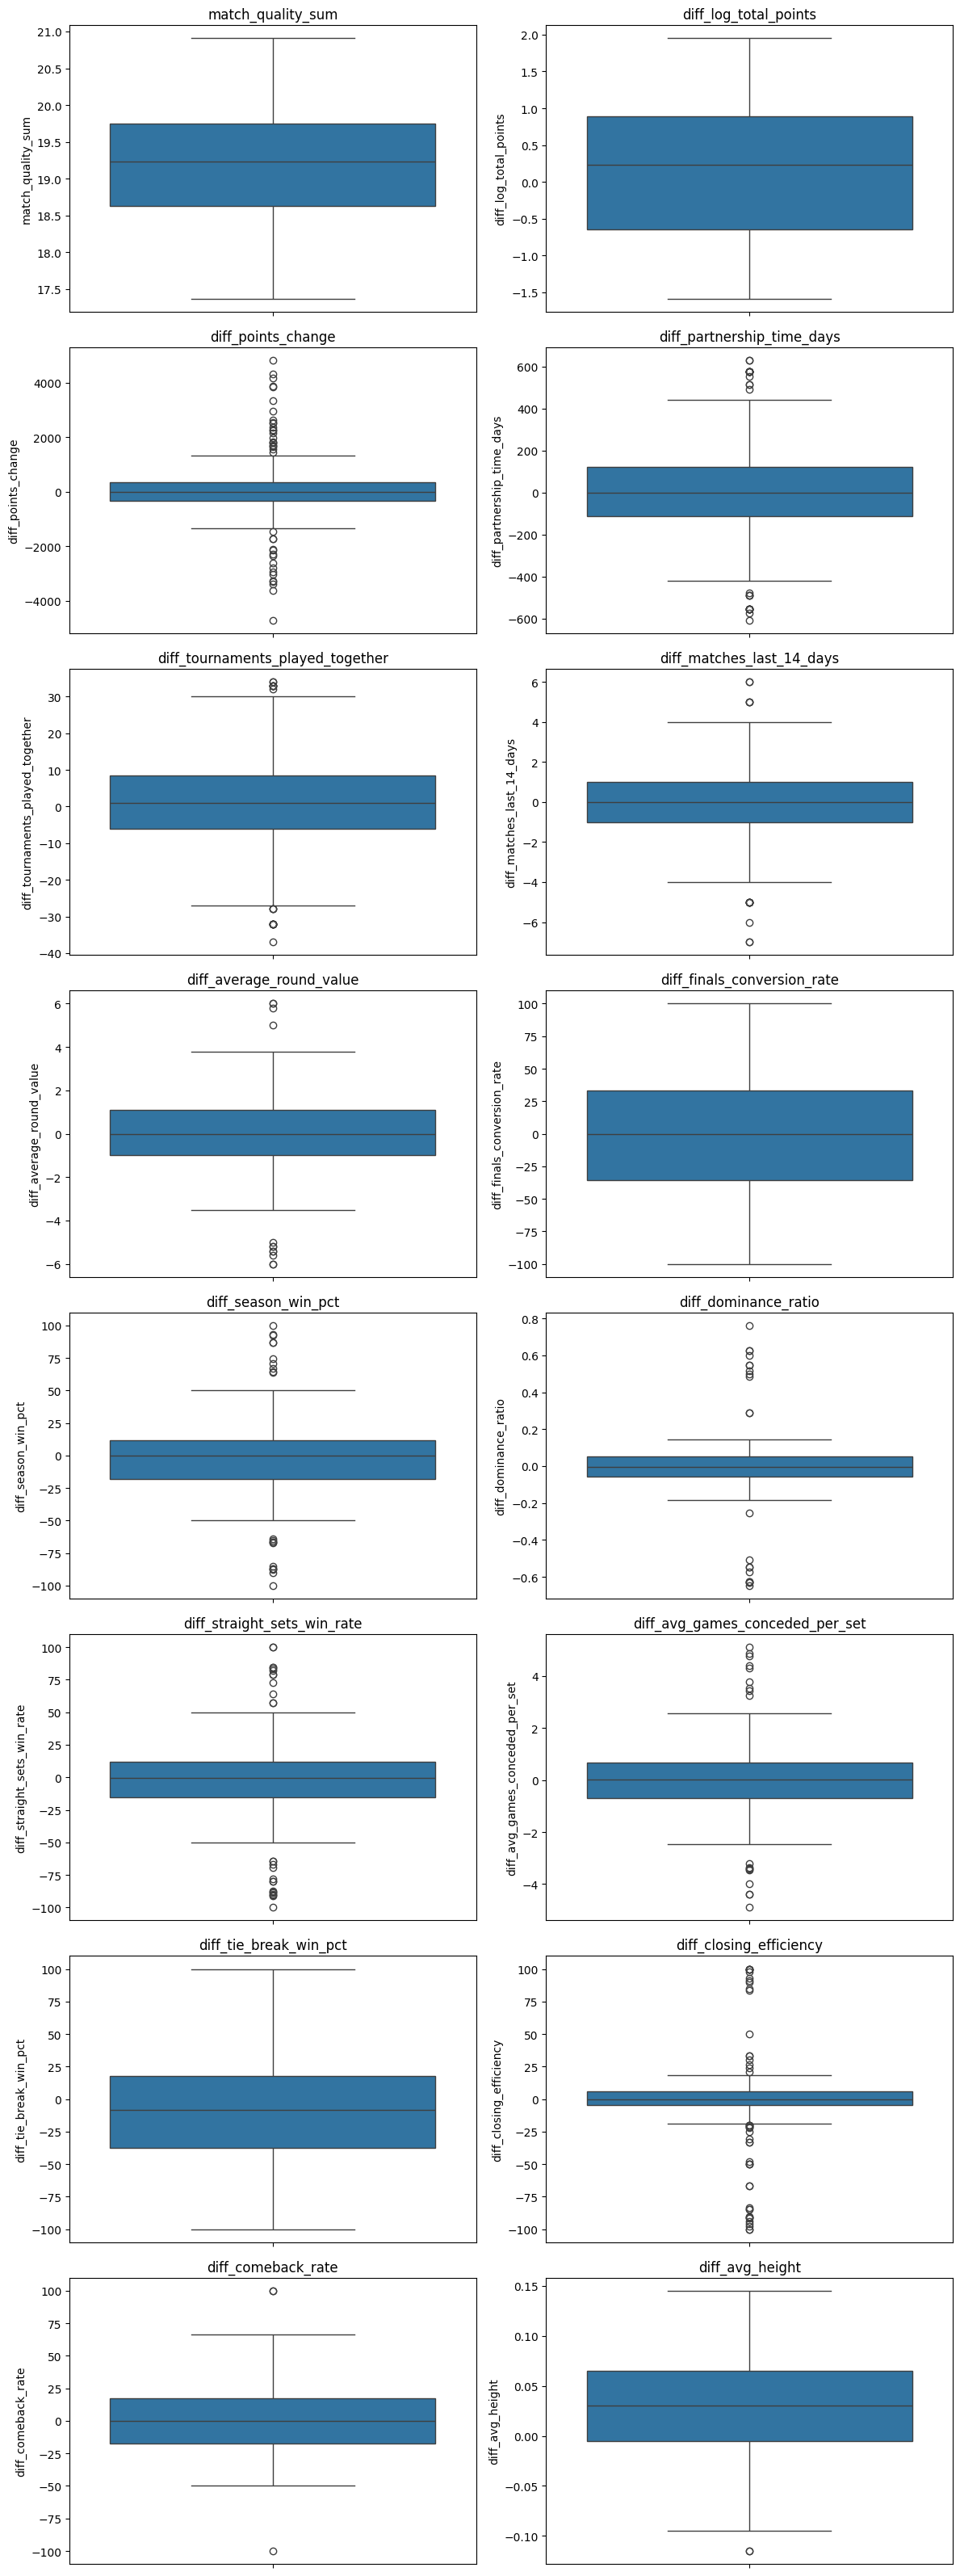

In [23]:
show_boxplot(df_model, ['match_quality_sum'] + [col for col in df_model.columns if col.startswith('diff_')], plots_per_row=2)

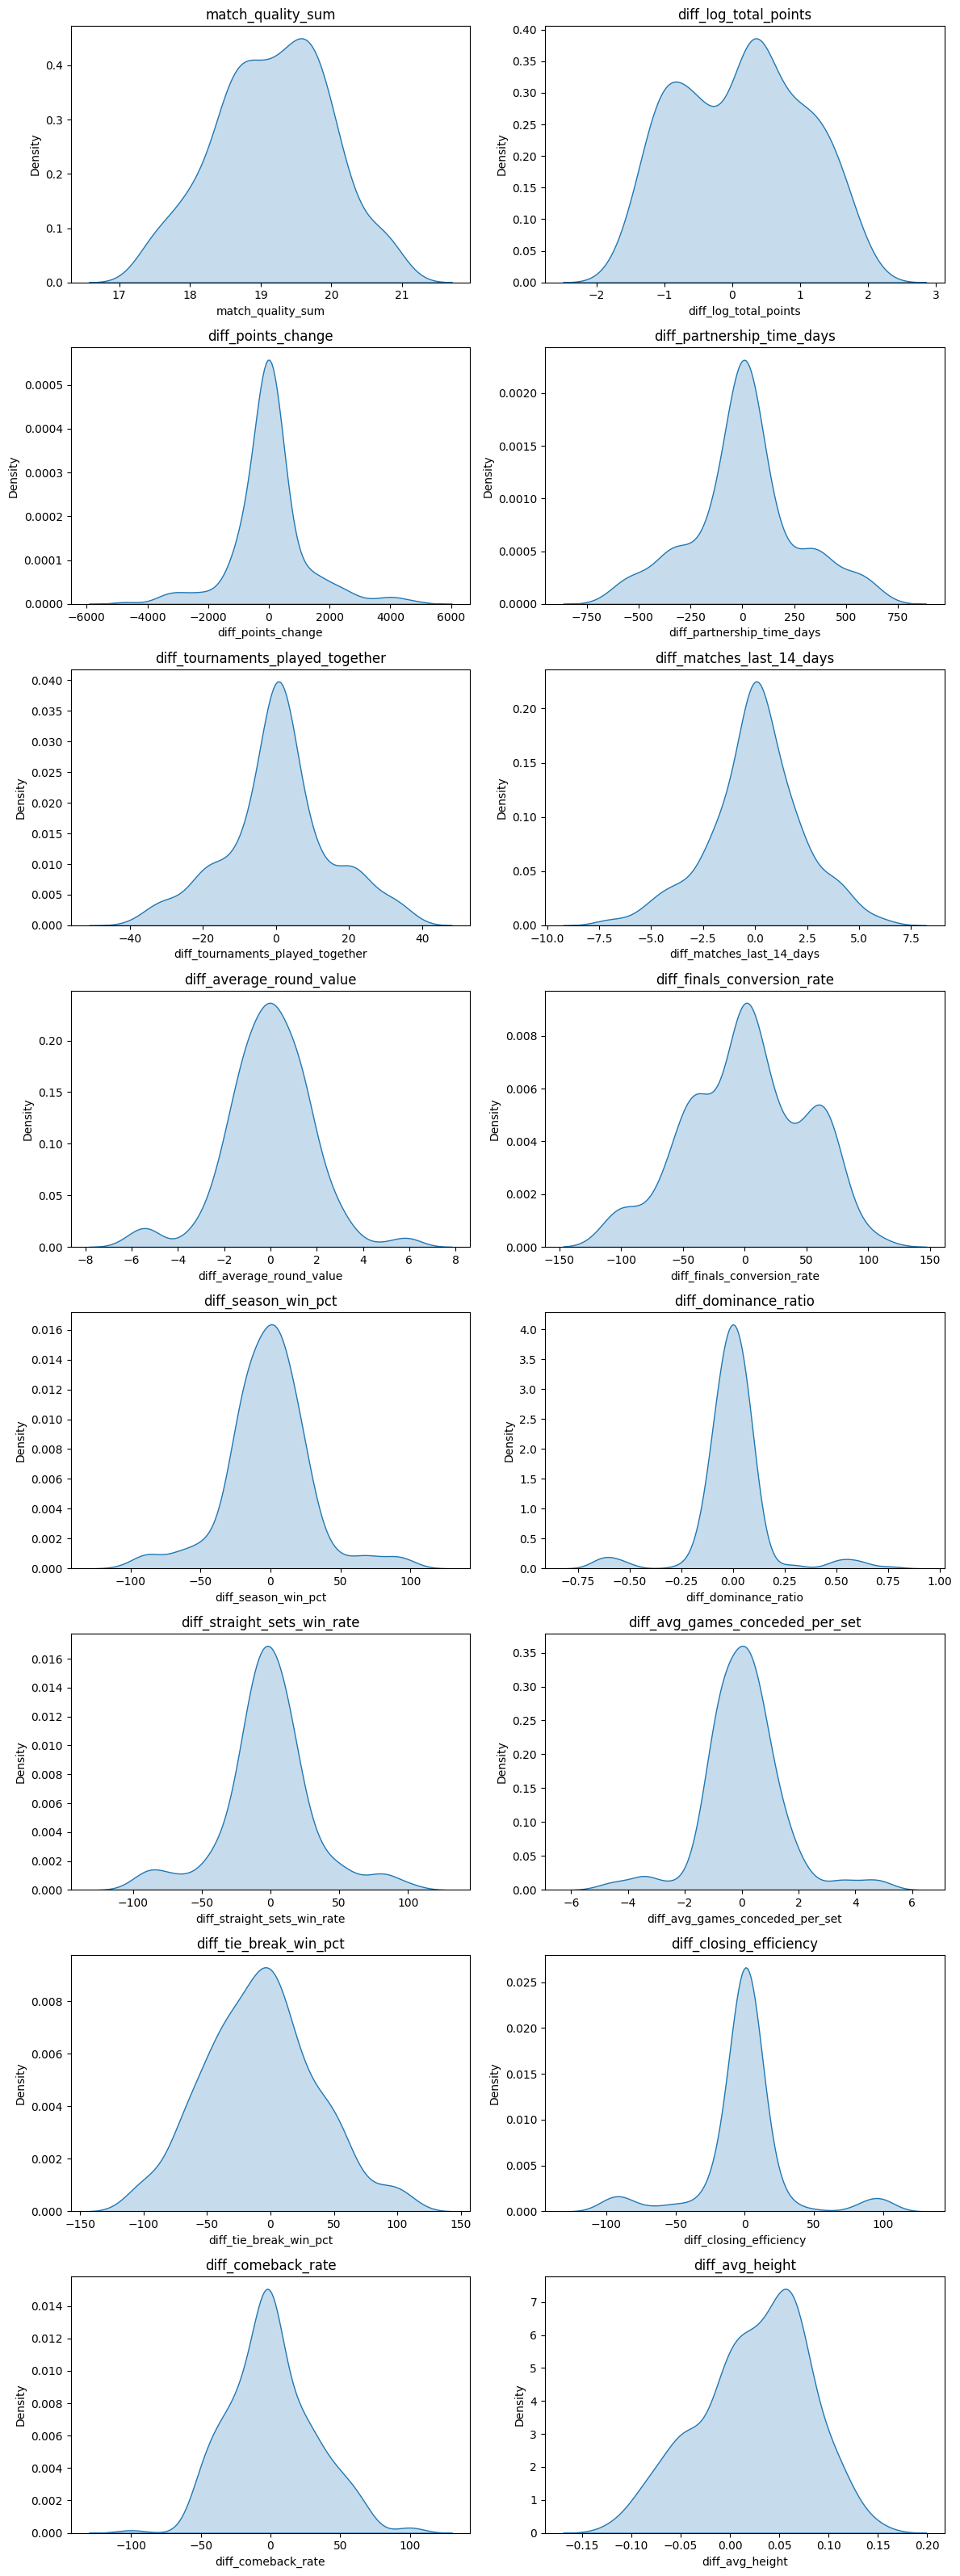

In [24]:
show_histogram(df_model, ['match_quality_sum'] + [col for col in df_model.columns if col.startswith('diff_')], plots_per_row=2)

Take advantage of outliers. In sports data they are the money makers!

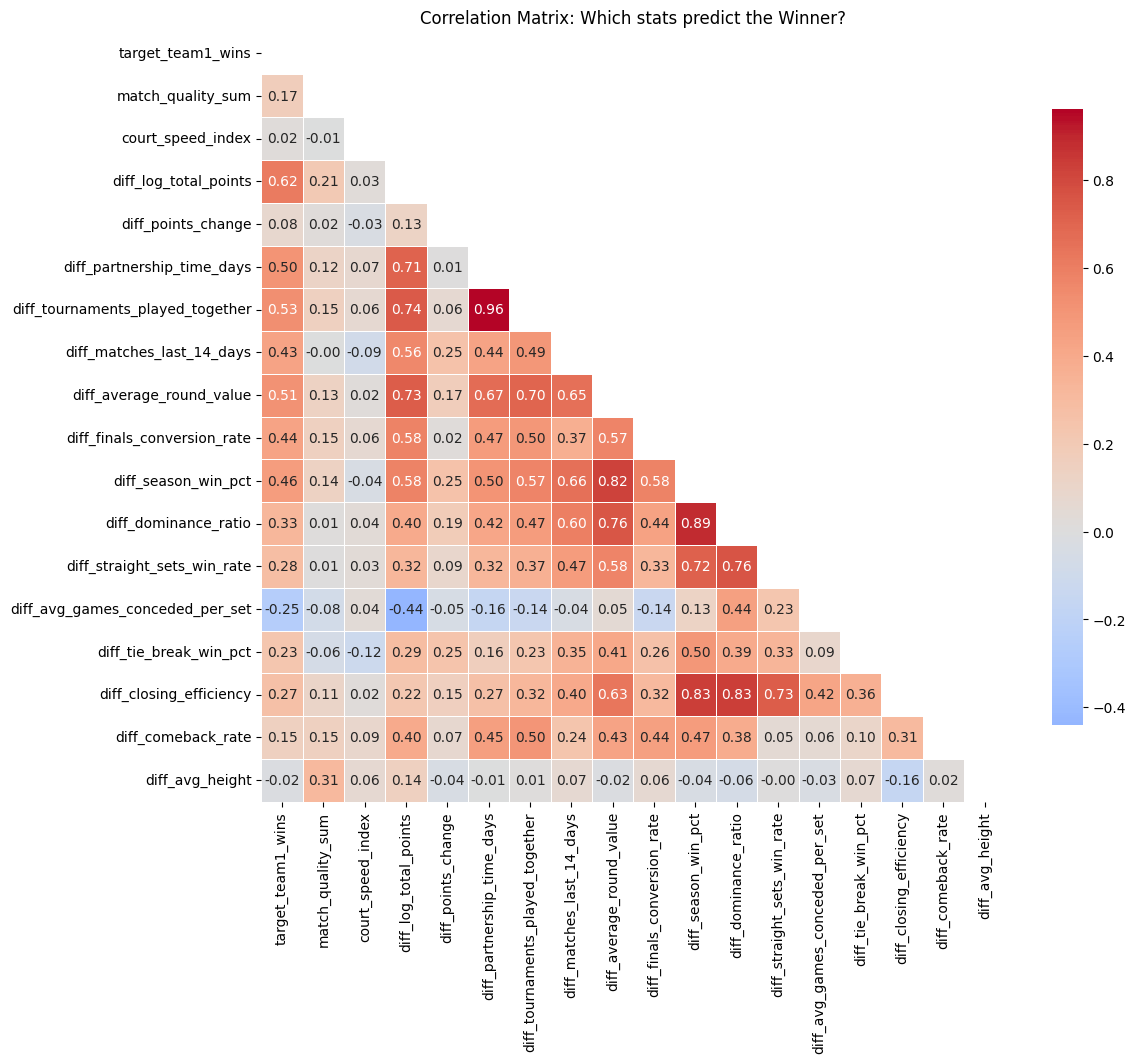

In [25]:
show_correlation_heatmap(df_model)

In [26]:
df_model_nocorr = df_model.copy()
df_model_nocorr = df_model_nocorr.drop(['diff_partnership_time_days', 'diff_closing_efficiency', 'diff_dominance_ratio', 'diff_average_round_value', 'diff_straight_sets_win_rate', 'altitude', 'avg_temperature', 'avg_humidity'], axis=1)

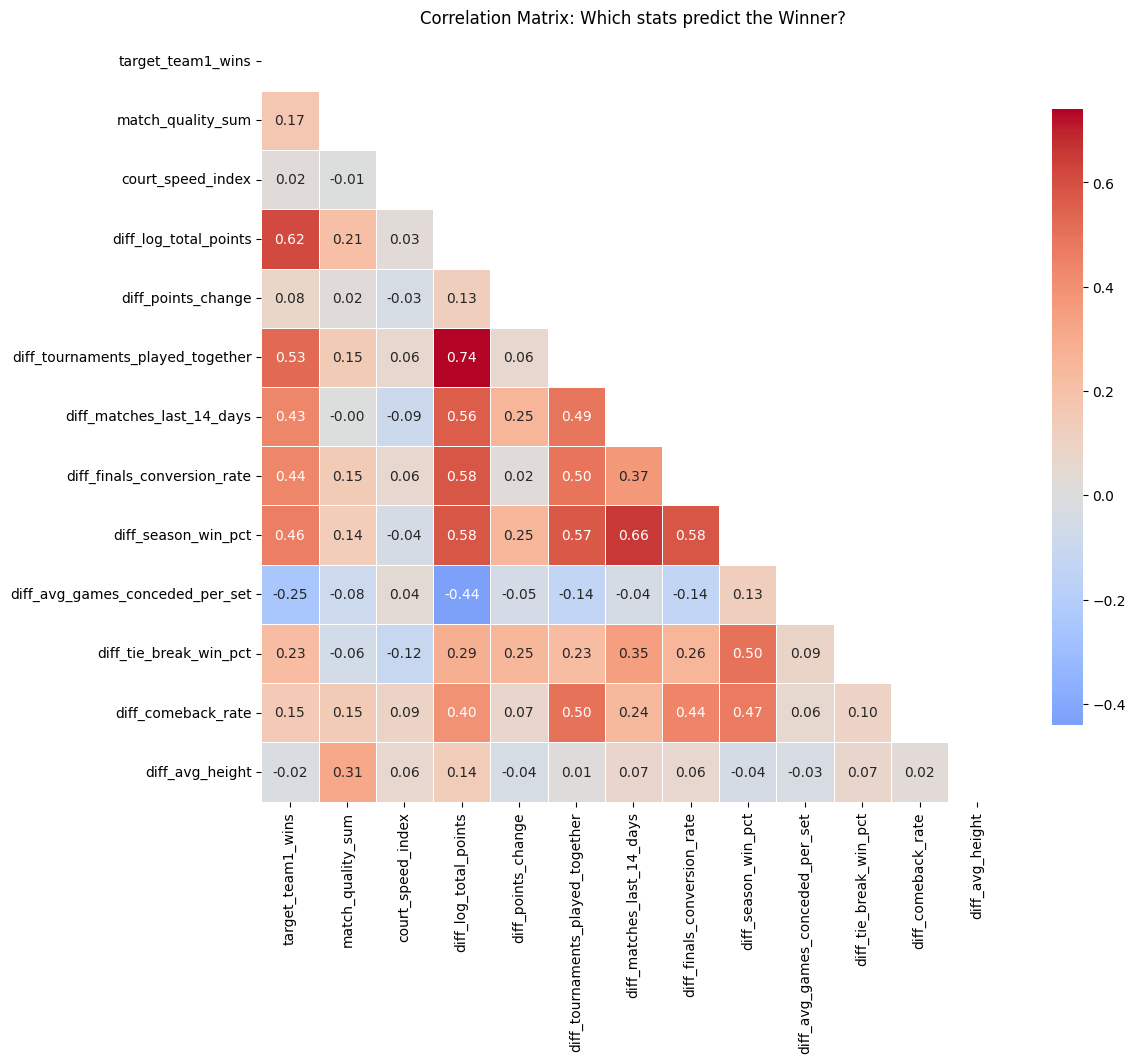

In [27]:
show_correlation_heatmap(df_model_nocorr)

In [28]:
# ---------------------------------------------------------
# DEFINE THE SYMMETRIZATION FUNCTION
# ---------------------------------------------------------
def prepare_symmetric_data(df):
    """
    Doubles the dataset by flipping Team 1 and Team 2.
    Ensures the model sees every match from both perspectives.
    """
    # Create the mirror copy
    df_flipped = df.copy()
    
    # Invert the target (If T1 won, now T2 wins)
    df_flipped['target_team1_wins'] = 1 - df_flipped['target_team1_wins']
    
    # Invert ONLY the difference columns
    # (Speed Index stays the same because the court doesn't change!)
    diff_cols = [c for c in df.columns if c.startswith('diff_')]
    df_flipped[diff_cols] = df_flipped[diff_cols] * -1
    df_flipped['team1_slug'], df_flipped['team2_slug'] = df_flipped['team2_slug'], df_flipped['team1_slug']
    # Combine and Sort by Date (Crucial for time splitting)
    df_sym = pd.concat([df, df_flipped], ignore_index=True)
    df_sym['date'] = pd.to_datetime(df_sym['date'])
    df_sym = df_sym.sort_values('date').reset_index(drop=True)
    
    return df_sym

df_model_symmetric = prepare_symmetric_data(df_model_nocorr)

In [30]:
df_model_symmetric.to_csv("C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\data\\model_ready_data.csv", index=False)

MODEL DEFINITIONS

In [31]:

SPLIT_DATE = '2025-10-01' 
START_DATE = '2024-05-01'
# Create Masks
train_mask = (df_model_symmetric['date'] < SPLIT_DATE) & (df_model_symmetric['date'] > START_DATE)
test_mask = df_model_symmetric['date'] >= SPLIT_DATE

# Define Features (X) and Target (y)
# We exclude ID columns and Date from the training features
feature_cols = [c for c in df_model_symmetric.columns if c.startswith('diff_') or c == 'court_speed_index' or c == 'match_quality_sum']
target_col = 'target_team1_wins'

X_train = df_model_symmetric.loc[train_mask, feature_cols]
y_train = df_model_symmetric.loc[train_mask, target_col]

X_test = df_model_symmetric.loc[test_mask, feature_cols]
y_test = df_model_symmetric.loc[test_mask, target_col]

# Save Meta-Data for later analysis (Who played?)
meta_test = df_model_symmetric.loc[test_mask, ['tournaments_match_id', 'date', 'target_team1_wins', 'team1_slug', 'team2_slug',]].copy()

print(f"Total Samples: {len(df_model_symmetric)}")
print(f"Train Set: {len(X_train)} rows")
print(f"Test Set:  {len(X_test)} rows")
print(f"Features: {len(feature_cols)}")

Total Samples: 494
Train Set: 390 rows
Test Set:  94 rows
Features: 12


In [32]:
feature_cols

['match_quality_sum',
 'court_speed_index',
 'diff_log_total_points',
 'diff_points_change',
 'diff_tournaments_played_together',
 'diff_matches_last_14_days',
 'diff_finals_conversion_rate',
 'diff_season_win_pct',
 'diff_avg_games_conceded_per_set',
 'diff_tie_break_win_pct',
 'diff_comeback_rate',
 'diff_avg_height']

In [33]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox

from time import time
from datetime import timedelta

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import f1_score, log_loss, roc_auc_score, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,VotingClassifier,GradientBoostingClassifier,StackingClassifier,ExtraTreesClassifier, AdaBoostClassifier, IsolationForest
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

In [34]:
def confusion(true, pred):
    """
    Function for pretty printing confusion matrices
    """
    pred = pd.Series(pred)
    true = pd.Series(true)
    
    true.name = 'target'
    pred.name = 'predicted'
    cm = pd.crosstab(true.reset_index(drop=True), pred.reset_index(drop=True))
    cm = cm[cm.index]
    return cm

def compute_metrics(y_true,y_pred, y_proba=None):
    """
    Evaluates a binary sports prediction model using:
    - F1-macro (primary)
    - Log loss (secondary, requires probabilities)
    - AUC-ROC (optional, requires probabilities)
    """
    f1_macro = f1_score(y_true, y_pred, average='macro')
    accuracy = accuracy_score(y_true, y_pred)
    # Secondary metrics (only if probabilities provided)
    if y_proba is not None:
        # Ensure probabilities are 1D (probability of class 1)
        if y_proba.ndim > 1:
            y_proba = y_proba[:, 1]

        logloss = log_loss(y_true, y_proba)
        auc = roc_auc_score(y_true, y_proba)
    else:
        logloss = None
        auc = None

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "log_loss": logloss,
        "auc_roc": auc
    }

    
results = pd.DataFrame(columns=['accuracy', 'f1_macro', 'log_loss', 'auc_roc'])
models = {}

In [35]:
X_train_LR = X_train.copy()
X_test_LR = X_test.copy()

pipe_LogReg_Normal = Pipeline([ ('scaler', StandardScaler()), ('model', LogisticRegression()) ])

model_LogisticRegression = pipe_LogReg_Normal.fit(X_train, y_train)

# Predictions (0/1)
y_pred = model_LogisticRegression.predict(X_test)

# Probabilities (for log loss + AUC)
y_proba = model_LogisticRegression.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate using your new metrics function
results.loc['LogReg', :] = compute_metrics(y_test, y_pred, y_proba)

# Save model
models['LogReg'] = model_LogisticRegression
results


,accuracy,f1_macro,log_loss,auc_roc
LogReg,0.808511,0.808511,0.35913,0.921684


In [36]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

param_grid = {
    # Regularization strength (C = 1/λ)
    'model__C': [
        0.0001, 0.0003, 0.001, 0.003,
        0.01, 0.03, 0.1, 0.3,
        1, 3, 10, 30, 100
    ],

    # Type of regularization
    'model__penalty': [
        'l1', 'l2', 'elasticnet', 'none'
    ],

    # Solvers (each supports different penalties)
    'model__solver': [
        'liblinear',     # supports l1, l2
        'lbfgs',         # supports l2, none
        'saga',          # supports l1, l2, elasticnet
        'newton-cg'      # supports l2, none
    ],

    # Elastic Net mixing (only used when penalty='elasticnet')
    'model__l1_ratio': [
        0.0, 0.1, 0.25, 0.5, 0.75, 0.9, 1.0
    ],

    # Max iterations (important for convergence)
    'model__max_iter': [
        200, 500, 1000, 2000
    ],

    # Tolerance for stopping
    'model__tol': [
        1e-4, 1e-5, 1e-6
    ]
}


search = RandomizedSearchCV(
    pipe,
    param_distributions=param_grid,
    cv=TimeSeriesSplit(n_splits=4),
    scoring='neg_log_loss',
    n_iter=10,
    n_jobs=-1,
    error_score=np.nan
)

model_LogisticRegression_Tuned = search.fit(X_train_LR, y_train)

y_pred = model_LogisticRegression_Tuned.predict(X_test)

# Probabilities (for log loss + AUC)
y_proba = model_LogisticRegression_Tuned.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate using your new metrics function
results.loc['LogRegTuned', :] = compute_metrics(y_test, y_pred, y_proba)

# Save model
models['LogRegTuned'] = model_LogisticRegression_Tuned
results

c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
12 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
4 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\U

,accuracy,f1_macro,log_loss,auc_roc
LogReg,0.808511,0.808511,0.35913,0.921684
LogRegTuned,0.808511,0.808511,0.352018,0.928022


In [37]:
model_XGBoost = XGBClassifier().fit(X_train,y_train)

y_pred = model_XGBoost.predict(X_test)

# Probabilities (for log loss + AUC)
y_proba = model_XGBoost.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate using your new metrics function
results.loc['XGBoost', :] = compute_metrics(y_test, y_pred, y_proba)

# Save model
models['XGBoost'] = model_XGBoost
results

,accuracy,f1_macro,log_loss,auc_roc
LogReg,0.808511,0.808511,0.35913,0.921684
LogRegTuned,0.808511,0.808511,0.352018,0.928022
XGBoost,0.765957,0.765957,0.442076,0.886374


In [38]:
param_grid_xgb = {
    'n_estimators': [200, 400, 600, 800, 1000],
    'learning_rate': [0.005, 0.01, 0.02, 0.05, 0.1],
    'max_depth': [2, 3, 4, 5, 6],
    'min_child_weight': [1, 3, 5, 7, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 1],
    'reg_alpha': [0, 0.001, 0.01, 0.1, 1],
    'reg_lambda': [0, 0.1, 1, 5],
}

tscv = TimeSeriesSplit(n_splits=4)

xgb_base = XGBClassifier(
    eval_metric='mlogloss',
)

search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=40,
    scoring='neg_log_loss',
    cv=tscv,
    n_jobs=-1,
    verbose=1
)

model_XGBoost_Tuned = search_xgb.fit(X_train, y_train)

y_pred = model_XGBoost_Tuned.predict(X_test)

# Probabilities (for log loss + AUC)
y_proba = model_XGBoost_Tuned.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate using your new metrics function
results.loc['XGBoost_Tuned', :] = compute_metrics(y_test, y_pred, y_proba)

# Save model
models['XGBoost_Tuned'] = model_XGBoost_Tuned
results



Fitting 4 folds for each of 40 candidates, totalling 160 fits


,accuracy,f1_macro,log_loss,auc_roc
LogReg,0.808511,0.808511,0.35913,0.921684
LogRegTuned,0.808511,0.808511,0.352018,0.928022
XGBoost,0.765957,0.765957,0.442076,0.886374
XGBoost_Tuned,0.851064,0.851064,0.438246,0.909235


In [39]:
model_VotingSoft = VotingClassifier([('LogRegTuned', model_LogisticRegression_Tuned), ('XGBoost_Tuned', model_XGBoost_Tuned)], voting='soft')
model_VotingSoft.fit(X_train, y_train)

y_pred = model_VotingSoft.predict(X_test)

# Probabilities (for log loss + AUC)
y_proba = model_VotingSoft.predict_proba(X_test)[:, 1]  # probability of class 1

# Evaluate using your new metrics function
results.loc['VotingSoft', :] = compute_metrics(y_test, y_pred, y_proba)

# Save model
models['VotingSoft'] = model_VotingSoft
results

c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\U

Fitting 4 folds for each of 40 candidates, totalling 160 fits


,accuracy,f1_macro,log_loss,auc_roc
LogReg,0.808511,0.808511,0.35913,0.921684
LogRegTuned,0.808511,0.808511,0.352018,0.928022
XGBoost,0.765957,0.765957,0.442076,0.886374
XGBoost_Tuned,0.851064,0.851064,0.438246,0.909235
VotingSoft,0.851064,0.851064,0.360356,0.931191


In [40]:
import pickle
MODEL_FILENAME = 'C:\\Users\\berna\\Desktop\\padel\\VoleAI2.0\\predictive_model\\ml\\models\\final_padel_model.pkl'

print(f"Saving model to {MODEL_FILENAME}...")
with open(MODEL_FILENAME, 'wb') as f:
    pickle.dump(model_VotingSoft, f)
with open(MODEL_FILENAME, 'rb') as f:
    model = pickle.load(f)
print(model)


Saving model to C:\Users\berna\Desktop\padel\VoleAI2.0\predictive_model\ml\models\final_padel_model.pkl...
VotingClassifier(estimators=[('LogRegTuned',
                              RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=4, test_size=None),
                                                 estimator=Pipeline(steps=[('scaler',
                                                                            StandardScaler()),
                                                                           ('model',
                                                                            LogisticRegression())]),
                                                 n_jobs=-1,
                                                 param_distributions={'model__C': [0.0001,
                                                                                   0.0003,
                                                                                   0.001,
                        